In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH = '../Data/clean_data/master_player_season.csv'
df = pd.read_csv(PATH)

In [3]:
df.head()

,player_id,season_id,team_code,age,games,games_started,minutes,win_shares,ws_per_48,bpm,...,bmi,agility,height_bin,position_id,position_code,mvp_rank,mvp_share,is_mvp_candidate,is_champion,season_name
0,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2020-21
1,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),4,PF,NaN,NaN,False,False,2020-21
2,achiupr01,3,TOR,22,73,28,1725,2.5,0.070,-2.6,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2021-22
3,achiupr01,3,TOR,22,73,28,1725,2.5,0.070,-2.6,...,26.693198,1.845455,Big-height (201-213cm),4,PF,NaN,NaN,False,False,2021-22
4,achiupr01,4,TOR,23,55,12,1140,2.2,0.093,-2.3,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2022-23


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         5853 non-null   str    
 1   season_id         5853 non-null   int64  
 2   team_code         5853 non-null   str    
 3   age               5853 non-null   int64  
 4   games             5853 non-null   int64  
 5   games_started     5853 non-null   int64  
 6   minutes           5853 non-null   int64  
 7   win_shares        5853 non-null   float64
 8   ws_per_48         5853 non-null   float64
 9   bpm               5853 non-null   float64
 10  vorp              5853 non-null   float64
 11  low_sample        5853 non-null   bool   
 12  experience        5853 non-null   int64  
 13  innate_ability    5853 non-null   float64
 14  full_name         5853 non-null   str    
 15  birth_date        5839 non-null   str    
 16  birth_place       5839 non-null   str    
 17  height

In [14]:
features = [
    'minutes',
    'win_shares',
    'ws_per_48',
    'vorp',
    'experience',
    'age'
]

sdf = df[features]

In [15]:
sdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   minutes     5853 non-null   int64  
 1   win_shares  5853 non-null   float64
 2   ws_per_48   5853 non-null   float64
 3   vorp        5853 non-null   float64
 4   experience  5853 non-null   int64  
 5   age         5853 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 274.5 KB


# Prepare the data

In [16]:
from sklearn.preprocessing import StandardScaler

X = sdf[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.44067186, -0.4079998 ,  0.046365  , -0.7986135 , -1.08639817,
        -1.17919669],
       [-0.44067186, -0.4079998 ,  0.046365  , -0.7986135 , -1.08639817,
        -1.17919669],
       [ 0.79965752,  0.05722211, -0.11098386, -0.64068513, -0.52940023,
        -0.95428587],
       ...,
       [ 0.88627971,  1.72426729,  1.06388762,  0.54377761,  1.1415936 ,
        -0.05464261],
       [ 1.92825683,  3.62392344,  1.41005512,  2.20202545,  1.69859154,
         0.17026821],
       [ 0.44940256,  0.71628649,  0.61282089, -0.00897167,  2.25558948,
         0.39517903]], shape=(5853, 6))

# Number of clusters

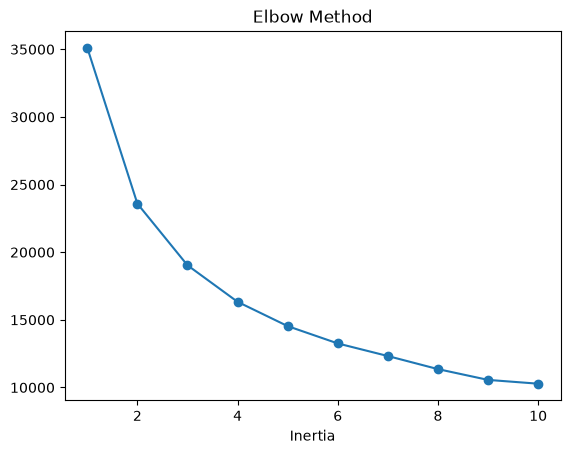

In [31]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)


plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.xlabel('Inertia')
plt.title('Elbow Method')
plt.savefig('plots/elbow.png')
plt.show()

# Train K-Means

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clean = df.loc[X.index].copy()
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [33]:
cluster_summary = df_clean.groupby("cluster")[features].mean()

print(cluster_summary.round(2))

         minutes  win_shares  ws_per_48  vorp  experience    age
cluster                                                         
0        2246.29        8.21       0.18  3.74        4.17  28.67
1         509.68        0.52       0.04 -0.10        1.82  23.54
2         903.60        1.51       0.08  0.17        4.72  30.87
3        1758.43        3.98       0.11  1.06        2.83  25.76


# Visualize with PCA

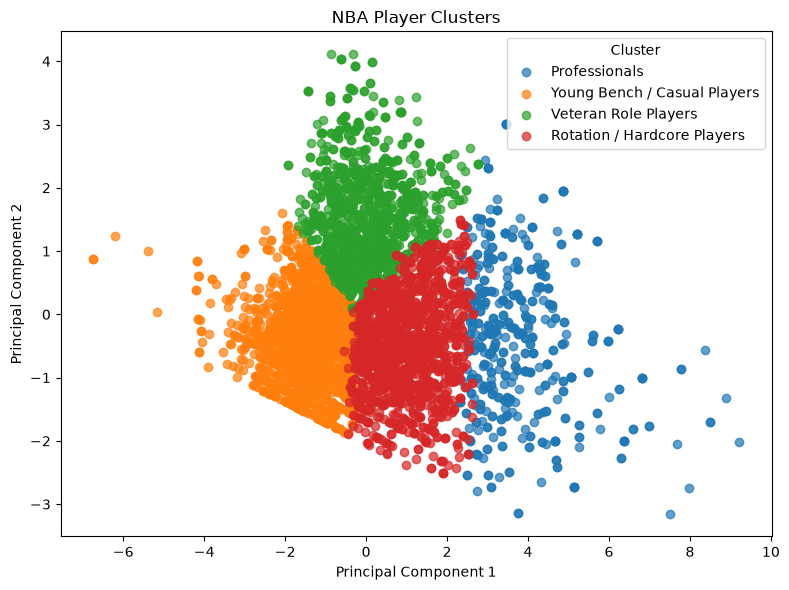

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cluster_names = {
    0: "Professionals",
    1: "Young Bench / Casual Players",
    2: "Veteran Role Players",
    3: "Rotation / Hardcore Players"
}

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for cluster in sorted(df_clean["cluster"].unique()):
    mask = df_clean["cluster"] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=cluster_names[cluster],
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("NBA Player Clusters")
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig("plots/player_clusters.png", dpi=300)
plt.show()

In [36]:
df_clean.value_counts('cluster')

cluster
1    2442
3    1576
2    1318
0     517
Name: count, dtype: int64

In [39]:
df_clean.sort_values("win_shares", ascending=False).groupby("cluster").head(2)

,player_id,season_id,team_code,age,games,games_started,minutes,win_shares,ws_per_48,bpm,...,agility,height_bin,position_id,position_code,mvp_rank,mvp_share,is_mvp_candidate,is_champion,season_name,cluster
2869,jokicni01,5,DEN,28,79,79,2737,17.0,0.299,13.2,...,1.648438,Big-height (201-213cm),1,C,1.0,0.935,True,False,2023-24,0
1896,gilgesh01,6,OKC,26,76,76,2598,16.7,0.309,11.5,...,2.250000,Wing-height (190-201cm),5,PG,1.0,0.913,True,True,2024-25,0
198,aytonde01,2,PHO,22,69,69,2115,8.4,0.191,1.2,...,1.868421,Big-height (201-213cm),1,C,NaN,NaN,False,False,2020-21,3
66,allenja01,1,BRK,21,70,64,1852,8.2,0.212,2.3,...,1.872727,Big-height (201-213cm),1,C,NaN,NaN,False,False,2019-20,3
1329,derozde01,7,SAC,36,77,77,2406,5.6,0.112,-0.1,...,2.000000,Wing-height (190-201cm),7,SG,NaN,NaN,False,False,2025-26,2
1328,derozde01,7,SAC,36,77,77,2406,5.6,0.112,-0.1,...,2.000000,Wing-height (190-201cm),6,SF,NaN,NaN,False,False,2025-26,2
935,cartewe01,1,CHI,20,43,43,1256,3.3,0.127,-2.4,...,1.704918,Big-height (201-213cm),1,C,NaN,NaN,False,False,2019-20,1
936,cartewe01,1,CHI,20,43,43,1256,3.3,0.127,-2.4,...,1.704918,Big-height (201-213cm),4,PF,NaN,NaN,False,False,2019-20,1


In [43]:
# Counts
print(pd.crosstab(df_clean["cluster"], df_clean["is_mvp_candidate"]))

# Percentages
print(
    (pd.crosstab(
        df_clean["cluster"],
        df_clean["is_mvp_candidate"],
        normalize="index"
    ) * 100).round(2)
)

is_mvp_candidate  False  True 
cluster                       
0                   361    156
1                  2442      0
2                  1318      0
3                  1573      3
is_mvp_candidate   False  True 
cluster                        
0                  69.83  30.17
1                 100.00   0.00
2                 100.00   0.00
3                  99.81   0.19


In [44]:
# Counts
print(pd.crosstab(df_clean["cluster"], df_clean["is_champion"]))

# Percentages
print(
    (pd.crosstab(
        df_clean["cluster"],
        df_clean["is_champion"],
        normalize="index"
    ) * 100).round(2)
)

is_champion  False  True 
cluster                  
0              482     35
1             2399     43
2             1294     24
3             1528     48
is_champion  False  True 
cluster                  
0            93.23   6.77
1            98.24   1.76
2            98.18   1.82
3            96.95   3.05


# Alter PlayerSeasonStats Table

In [48]:
cluster_df = df_clean[['player_id', 'season_id', 'cluster']]

In [50]:
cluster_df.head()

,player_id,season_id,cluster
0,achiupr01,2,1
1,achiupr01,2,1
2,achiupr01,3,3
3,achiupr01,3,3
4,achiupr01,4,1


## I needed to do this in docker exec first
ALTER TABLE PlayerSeasonStats
ADD COLUMN cluster INT;

In [57]:
from sqlalchemy import text, create_engine
from dotenv import load_dotenv
import os

# LOAD ENV VARIABLES FROM DOCKER MYSQL
load_dotenv('../metabase/.env-docker', override=True)
DOCKER_USERNAME = os.getenv('DB_USERNAME')
DOCKER_PASSWORD = os.getenv('PASSWORD')
DOCKER_HOST = os.getenv('HOST')
DOCKER_PORT = os.getenv('PORT')
DOCKER_DATABASE = os.getenv('DATABASE')

print("Destination Docker MySQL (from .env-docker):")
print(f"Username: {DOCKER_USERNAME}")
print(f"Password: {'*' * len(DOCKER_PASSWORD) if DOCKER_PASSWORD else 'None'}")
print(f"Host: {DOCKER_HOST}")
print(f"Port: {DOCKER_PORT}")
print(f"Database: {DOCKER_DATABASE}\n")

engine = create_engine(
    f"mysql+pymysql://{DOCKER_USERNAME}:{DOCKER_PASSWORD}@{DOCKER_HOST}:{DOCKER_PORT}/{DOCKER_DATABASE}"
)

with engine.begin() as conn:
    for _, row in cluster_df.iterrows():
        conn.execute(
            text("""
                UPDATE playerseasonstats
                SET cluster = :cluster
                WHERE player_id = :player_id
                  AND season_id = :season_id
            """),
            {
                "cluster": int(row.cluster),
                "player_id": row.player_id,
                "season_id": int(row.season_id)
            }
        )

Destination Docker MySQL (from .env-docker):
Username: root
Password: ************
Host: localhost
Port: 3307
Database: nba_analysis

